In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import math
from sklearn import tree
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv('lab3_dataset.csv')
print(df.isnull().sum())
df.head()

age                         0
likes_dog                   0
likes_gravity               0
going_to_be_an_astronaut    0
dtype: int64


,age,likes_dog,likes_gravity,going_to_be_an_astronaut
0,24,0,0,0
1,30,1,1,1
2,36,0,1,1
3,36,0,0,0
4,42,0,0,0


In [63]:
X = df.drop('going_to_be_an_astronaut', axis=1)
y = df['going_to_be_an_astronaut']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [64]:
modelGini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=5)
modelGini.fit(X_train, y_train)
pred = modelGini.predict(X_test)

In [65]:
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
# The accuracy is 0.4286, meaning the model correctly predicted 42.86% of the test cases.
# The precision is 1.0, meaning 100% of the cases predicted as positive were actually positive.
# The recall is 0.4286, meaning the model identified 42.86% of the actual positive cases.
# The model performs reasonably well in terms of precision, but it has a moderate recall, indicating that it misses some positive cases. 
# The accuracy is also moderate so the model could also predict better.

Accuracy: 0.5714285714285714
Precision: 1.0
Recall: 0.5714285714285714


In [66]:
modelEntropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=5)
modelEntropy.fit(X_train, y_train)
pred = modelEntropy.predict(X_test)

In [67]:
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
# The accuracy is 0.2857, meaning the model correctly predicted 28.57% of the test cases.
# The precision is 1.0, meaning 100% of the cases predicted as positive were actually positive.
# The recall is 0.2857, meaning the model identified 28.57% of the actual positive cases.
# The model performs well in terms of precision, but it has a low recall, meaning it misses a significant number of positive cases.
# The accuracy is also low so the model could also predict better.

Accuracy: 0.2857142857142857
Precision: 1.0
Recall: 0.2857142857142857


In [68]:
# Gini had the higher accuracy and recall.
# The reason why might be that the Gini criterion is more effective at finding the optimal splits in the data, leading to a better performing model.

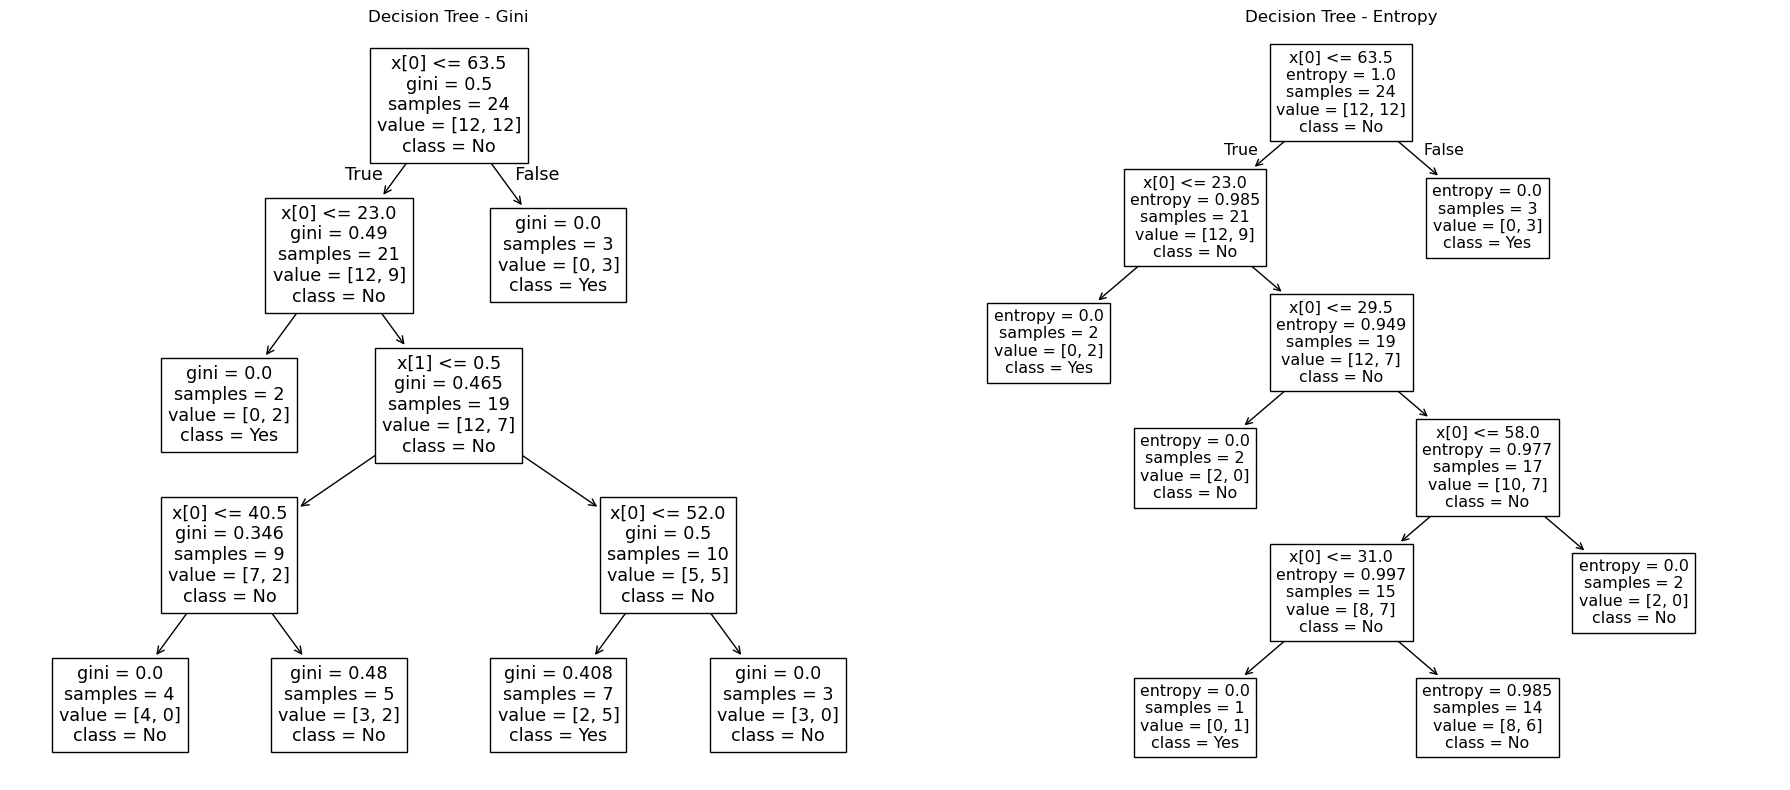

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

tree.plot_tree(modelGini, class_names=['No', 'Yes'], ax=ax[0])
ax[0].set_title("Decision Tree - Gini")

tree.plot_tree(modelEntropy, class_names=['No', 'Yes'], ax=ax[1])
ax[1].set_title("Decision Tree - Entropy")

plt.tight_layout()
plt.show()

In [70]:
new_student = pd.DataFrame([[33, 1, 0]], columns=X.columns)
prediction = modelGini.predict(new_student)[0]
print(prediction)
# The model predicts that the new student will not become an astronaut.

1


In [71]:
giniResults = []
entropyResults = []

for i in range(1, 22):
    giniModel = DecisionTreeClassifier(criterion='gini', max_depth=i, random_state=5)
    giniModel.fit(X_train, y_train)
    predGini = giniModel.predict(X_test)
    accuracyGini = accuracy_score(y_test, predGini)
    giniResults.append((i, accuracyGini))

    entropyModel = DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state=5)
    entropyModel.fit(X_train, y_train)
    predEntropy = entropyModel.predict(X_test)
    accuracyEntropy = accuracy_score(y_test, predEntropy)
    entropyResults.append((i, accuracyEntropy))

maxGiniDepth = max(giniResults, key=lambda x: x[1])[0]
maxEntropyDepth = max(entropyResults, key=lambda x: x[1])[0]

print("Max Gini Depth:", maxGiniDepth)
print("Max Entropy Depth:", maxEntropyDepth)
# Gini and entropy choose different splits at each level of the tree, which leads to the depth being different.

Max Gini Depth: 4
Max Entropy Depth: 6


In [72]:
counts = y_train.value_counts()

pYes = counts[1] / len(y_train)
pNo = counts[0] / len(y_train)

rootEntropy = -pYes * math.log2(pYes) - pNo * math.log2(pNo)

print("Root Entropy:", rootEntropy)

Root Entropy: 1.0


In [73]:
pivotTable = pd.pivot_table(df, index='likes_dog', columns='going_to_be_an_astronaut', aggfunc='size')
print(pivotTable)

going_to_be_an_astronaut  0   1
likes_dog                      
0                         7   7
1                         5  12


In [74]:
noDogNo = int(pivotTable.loc[0, 0])
noDogYes = int(pivotTable.loc[0, 1])
dogNo = int(pivotTable.loc[1, 0])
dogYes = int(pivotTable.loc[1, 1])

noDogEntropy = - (noDogYes / (noDogYes + noDogNo)) * math.log2(noDogYes / (noDogYes + noDogNo)) - (noDogNo / (noDogYes + noDogNo)) * math.log2(noDogNo / (noDogYes + noDogNo))
dogEntropy = - (dogYes / (dogYes + dogNo)) * math.log2(dogYes / (dogYes + dogNo)) - (dogNo / (dogYes + dogNo)) * math.log2(dogNo / (dogYes + dogNo))

print("Entropy for not liking dogs:", noDogEntropy)
print("Entropy for liking dogs:", dogEntropy)

total = noDogNo + noDogYes + dogNo + dogYes

rootCounts = df['going_to_be_an_astronaut'].value_counts()
rootYes = rootCounts[1]
rootNo = rootCounts[0]

rootEntropy = - (rootYes / total) * math.log2(rootYes / total) - (rootNo / total) * math.log2(rootNo / total)
weightedEntropy = (noDogYes + noDogNo) / total * (- (noDogYes / (noDogYes + noDogNo)) * math.log2(noDogYes / (noDogYes + noDogNo)) - (noDogNo / (noDogYes + noDogNo)) * math.log2(noDogNo / (noDogYes + noDogNo))) + (dogYes + dogNo) / total * (- (dogYes / (dogYes + dogNo)) * math.log2(dogYes / (dogYes + dogNo)) - (dogNo / (dogYes + dogNo)) * math.log2(dogNo / (dogYes + dogNo)))

informationGain = rootEntropy - weightedEntropy

print("Information gain:", informationGain)

#The information gain is small, which meanings that likes dogs is not a very strong predictor by itself.

Entropy for not liking dogs: 1.0
Entropy for liking dogs: 0.8739810481273578
Information gain: 0.03200758192729203
